# Denoising Autoencoder Tutorial Notebook
## Learning robust representations on Fashion-MNIST

This notebook reproduces the experiments for the assignment tutorial.
It compares a plain autoencoder with denoising autoencoders across different noise levels and bottleneck sizes.

### 1. Install / import packages
Uncomment the pip line if needed in a fresh environment.

### Code Block 1: Import libraries and set up the environment

This code cell imports all the packages needed for the tutorial and sets up the experiment so that results are reproducible.

**What this block does**
- imports the core Python libraries for file handling and iteration
- imports **NumPy** and **Pandas** for numerical work and tabular results
- imports **Matplotlib** for plotting figures
- imports the required tools from **scikit-learn** for data splitting, PCA, logistic regression, and accuracy evaluation
- imports **TensorFlow / Keras** to build and train the autoencoder models
- sets a fixed random seed so that the same train/validation split and similar model behaviour can be reproduced
- creates folders for saving figures and outputs generated by the notebook

**Why this matters**
A machine learning experiment should be reproducible. By fixing the random seed and organising output folders at the start, the notebook becomes easier for the marker to run and verify.



In [ ]:
# !pip install tensorflow numpy pandas matplotlib scikit-learn
import os, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


### 2. Load and inspect Fashion-MNIST

### Code Block 2: Load, normalise, and split the Fashion-MNIST dataset

This code cell loads the Fashion-MNIST dataset, scales the pixel values, and creates a validation split from the training data.

**What this block does**
- loads the Fashion-MNIST training and test sets directly from Keras
- stores the class names so figures can be labelled clearly
- converts image data to `float32`
- normalises pixel values from the original range of **0–255** to **0–1**
- splits the original training set into a new **training set** and **validation set**

**Why this matters**
Neural networks usually train better when inputs are scaled to a small range such as 0 to 1. The validation set is essential because it lets us assess model performance during training without touching the test set.



In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Validation split from the training set
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

print('Train:', x_train.shape, y_train.shape)
print('Val:  ', x_val.shape, y_val.shape)
print('Test: ', x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (54000, 28, 28) (54000,)
Val:   (6000, 28, 28) (6000,)
Test:  (10000, 28, 28) (10000,)


### Code Block 3: Display example images from Fashion-MNIST

This code cell plots a small sample of training images to give a quick visual overview of the dataset.

**What this block does**
- creates a grid of subplots
- displays the first ten training images in grayscale
- adds the class label as the title of each image
- removes axis ticks to keep the figure clean
- saves the figure for later use in the report or GitHub repository

**Why this matters**
Before training any model, it is important to understand what the input data looks like. This figure helps explain the type of visual patterns the autoencoder must learn to represent and reconstruct.



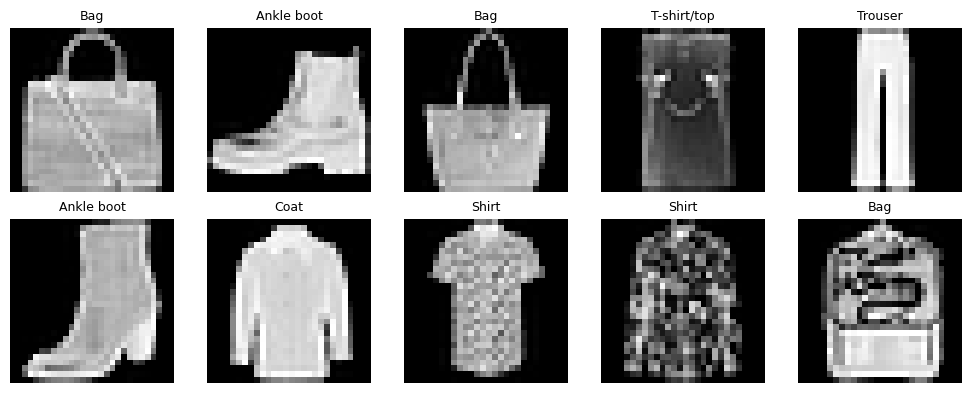

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sample_images.png', dpi=200, bbox_inches='tight')
plt.show()

### 3. Utility functions

### Code Block 4: Define helper functions and build the autoencoder architecture

This code cell contains the utility functions used throughout the notebook, including the noise function, image flattening function, and the model-building function.

**What this block does**
- defines a function to add **Gaussian noise** to input images
- clips noisy images so pixel values remain between 0 and 1
- defines a function to flatten 28×28 images into 784-dimensional vectors
- defines a function that builds the autoencoder and a matching encoder model
- creates an **undercomplete architecture** with a bottleneck layer that forces compression

**Why this matters**
A denoising autoencoder works by receiving corrupted inputs and learning to reconstruct the clean originals. The helper functions make this process reusable and keep the notebook tidy. The bottleneck is especially important because it forces the model to learn a compact representation rather than simply memorising the input.



In [ ]:
def add_gaussian_noise(images, noise_std=0.3):
    noisy = images + np.random.normal(loc=0.0, scale=noise_std, size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

def flatten_images(images):
    return images.reshape(len(images), -1)

def build_autoencoder(input_dim=784, bottleneck_dim=32):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)
    bottleneck = layers.Dense(bottleneck_dim, activation='relu', name='bottleneck')(x)
    x = layers.Dense(128, activation='relu')(bottleneck)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    autoencoder = keras.Model(inputs, outputs, name=f'ae_{bottleneck_dim}')
    encoder = keras.Model(inputs, bottleneck, name=f'encoder_{bottleneck_dim}')
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder, encoder

x_train_flat = flatten_images(x_train)
x_val_flat = flatten_images(x_val)
x_test_flat = flatten_images(x_test)

### 4. Visualise corruption levels

### Code Block 5: Visualise different corruption levels

This code cell creates a figure showing how the same images look when different amounts of Gaussian noise are added.

**What this block does**
- defines three corruption settings: 0.1, 0.3, and 0.5
- applies each noise level to a small group of images
- plots the corrupted outputs in rows so they can be compared visually
- saves the figure for use in the final report

**Why this matters**
The assignment focuses on how noise level changes model behaviour. This figure helps the reader understand what the model is being asked to recover. It also makes the tutorial more accessible because the effect of low, moderate, and high corruption is visible immediately.



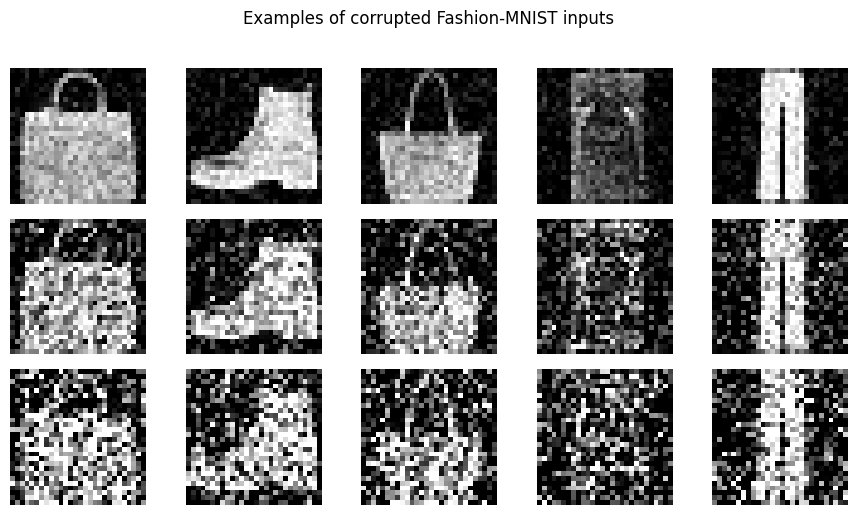

In [ ]:
noise_levels = [0.1, 0.3, 0.5]
fig, axes = plt.subplots(len(noise_levels), 5, figsize=(9, 5))
for r, noise in enumerate(noise_levels):
    noisy = add_gaussian_noise(x_train[:5], noise)
    for c in range(5):
        axes[r, c].imshow(noisy[c], cmap='gray')
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(f'noise={noise}', fontsize=10)
plt.suptitle('Examples of corrupted Fashion-MNIST inputs', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/corruption_examples.png', dpi=200, bbox_inches='tight')
plt.show()

### 5. Train a plain autoencoder baseline

### Code Block 6: Train the plain autoencoder baseline

This code cell trains a standard autoencoder without input corruption. It acts as the baseline model for comparison with the denoising autoencoders.

**What this block does**
- sets a baseline bottleneck size
- builds the standard autoencoder and its encoder
- creates an early stopping callback to reduce overfitting and unnecessary computation
- trains the model to reconstruct clean inputs from clean inputs
- stores the training history so validation loss can be plotted later

**Why this matters**
A baseline is needed to show whether denoising actually provides an advantage. Without this comparison, it would be difficult to judge if the denoising autoencoder is truly learning more robust features.



In [ ]:
baseline_bottleneck = 32
baseline_ae, baseline_encoder = build_autoencoder(bottleneck_dim=baseline_bottleneck)
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

history_baseline = baseline_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_val_flat, x_val_flat),
    epochs=20,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - loss: 0.3407 - val_loss: 0.3046
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.2986 - val_loss: 0.2943
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.2912 - val_loss: 0.2891
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.2871 - val_loss: 0.2856
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.2843 - val_loss: 0.2832
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.2820 - val_loss: 0.2814
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.2804 - val_loss: 0.2800
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.2791 - val_loss: 0.2789
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.2780 - val_loss: 0.2778
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.2769 - val_loss: 0.2770
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.2761 - val_loss: 0.2763
Epoch 12/20
422/422 ━━━━━━━━━━━━━

### 6. Train denoising autoencoders across settings

### Code Block 7: Train denoising autoencoders across all experiment settings

This is the main experimental cell in the notebook. It trains multiple denoising autoencoders by combining several bottleneck sizes with several noise levels.

**What this block does**
- defines the list of bottleneck sizes and noise levels to test
- loops through every combination of these settings
- corrupts the training and validation images using the chosen noise level
- trains a denoising autoencoder on each combination
- records the best validation loss for each trained model
- stores the trained models, encoders, and histories for later analysis
- builds a results table summarising the experiment

**Why this matters**
This block turns the tutorial into a structured investigation rather than a single demonstration. By systematically comparing multiple settings, the notebook can show how compression strength and corruption level influence reconstruction performance.



In [ ]:
bottlenecks = [16, 32, 64]
noise_levels = [0.1, 0.3, 0.5]
results = []
histories = {}
models = {}
encoders = {}

for bottleneck_dim, noise_std in itertools.product(bottlenecks, noise_levels):
    print(f'\nTraining bottleneck={bottleneck_dim}, noise={noise_std}')
    model, encoder = build_autoencoder(bottleneck_dim=bottleneck_dim)
    x_train_noisy = flatten_images(add_gaussian_noise(x_train, noise_std))
    x_val_noisy = flatten_images(add_gaussian_noise(x_val, noise_std))
    history = model.fit(
        x_train_noisy, x_train_flat,
        validation_data=(x_val_noisy, x_val_flat),
        epochs=20,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )
    val_loss = min(history.history['val_loss'])
    results.append({'bottleneck': bottleneck_dim, 'noise': noise_std, 'best_val_loss': val_loss})
    histories[(bottleneck_dim, noise_std)] = history.history
    models[(bottleneck_dim, noise_std)] = model
    encoders[(bottleneck_dim, noise_std)] = encoder

results_df = pd.DataFrame(results).sort_values(['bottleneck','noise']).reset_index(drop=True)
results_df


Training bottleneck=16, noise=0.1
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.3481 - val_loss: 0.3082
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.3023 - val_loss: 0.2978
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 0.2952 - val_loss: 0.2933

Training bottleneck=16, noise=0.3
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.3535 - val_loss: 0.3149
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.3082 - val_loss: 0.3042
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.3015 - val_loss: 0.2998

Training bottleneck=16, noise=0.5
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.3638 - val_loss: 0.3232
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.3168 - val_loss: 0.3129
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.3097 - val_loss: 0.3083

Training bottleneck=32, noise=0.1
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.3439 - v

,bottleneck,noise,best_val_loss
0,16,0.1,0.293291
1,16,0.3,0.299808
2,16,0.5,0.308294
3,32,0.1,0.290067
4,32,0.3,0.296428
5,32,0.5,0.308600
6,64,0.1,0.287909
7,64,0.3,0.297919
8,64,0.5,0.310567


### 7. Compare validation losses

### Code Block 8: Create a heatmap comparing validation losses

This code cell visualises the best validation loss from each experiment setting in the form of a heatmap.

**What this block does**
- reshapes the results table into a pivot table
- places bottleneck size on one axis and noise level on the other
- uses colour intensity to show differences in validation loss
- labels the axes and adds a colour bar
- saves the figure for the final report

**Why this matters**
A heatmap provides an immediate summary of which combinations perform best. This is more effective than listing numbers in text because the reader can see the trade-offs at a glance.



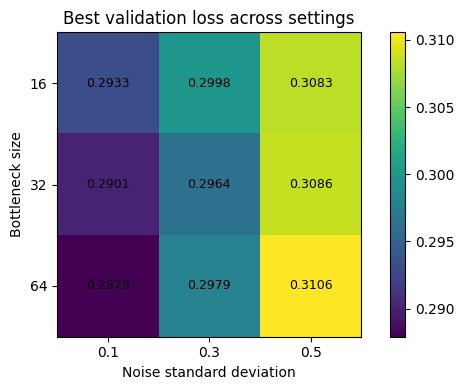

In [ ]:
pivot = results_df.pivot(index='bottleneck', columns='noise', values='best_val_loss')
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(i) for i in pivot.index])
ax.set_xlabel('Noise standard deviation')
ax.set_ylabel('Bottleneck size')
ax.set_title('Best validation loss across settings')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i,j]:.4f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/loss_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

### 8. Plot selected learning curves

### Code Block 9: Plot selected learning curves

This code cell plots the validation loss over time for several denoising autoencoder settings and the plain autoencoder baseline.

**What this block does**
- selects a small set of representative denoising models
- plots the validation loss at each training epoch
- overlays the baseline autoencoder curve for comparison
- labels the axes and legend clearly
- saves the learning-curve figure

**Why this matters**
Learning curves help show not only which model performed best, but also how stable the training process was. They can reveal whether a model converged quickly, improved steadily, or stopped improving early.



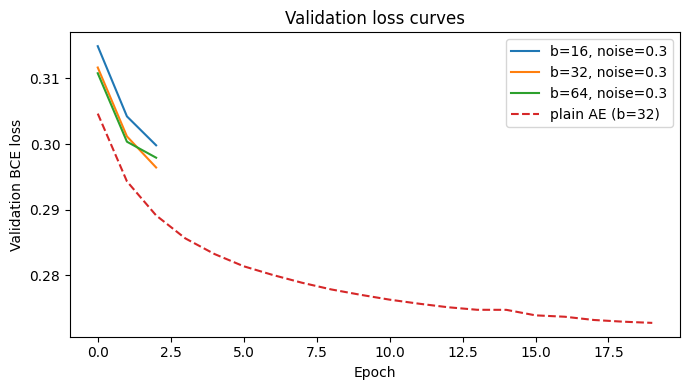

In [ ]:
selected = [(16, 0.3), (32, 0.3), (64, 0.3)]
fig, ax = plt.subplots(figsize=(7, 4))
for key in selected:
    h = histories[key]
    ax.plot(h['val_loss'], label=f'b={key[0]}, noise={key[1]}')
ax.plot(history_baseline.history['val_loss'], linestyle='--', label='plain AE (b=32)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation BCE loss')
ax.set_title('Validation loss curves')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/validation_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()

### 9. Visual comparison: original vs noisy vs reconstruction

### Code Block 10: Compare original, noisy, and reconstructed images

This code cell identifies the best-performing denoising autoencoder and uses it to reconstruct a sample of noisy test images.

**What this block does**
- finds the model with the lowest validation loss
- applies the corresponding noise level to a small batch of test images
- generates reconstructions using the best model
- plots the clean image, noisy input, and reconstructed output side by side
- saves the reconstruction figure

**Why this matters**
This is one of the most important teaching figures in the tutorial. It shows visually whether the model has learned to recover structure from corrupted images. It also makes the experiment intuitive for readers who may not be comfortable with loss values alone.



Best configuration: (64, 0.1)


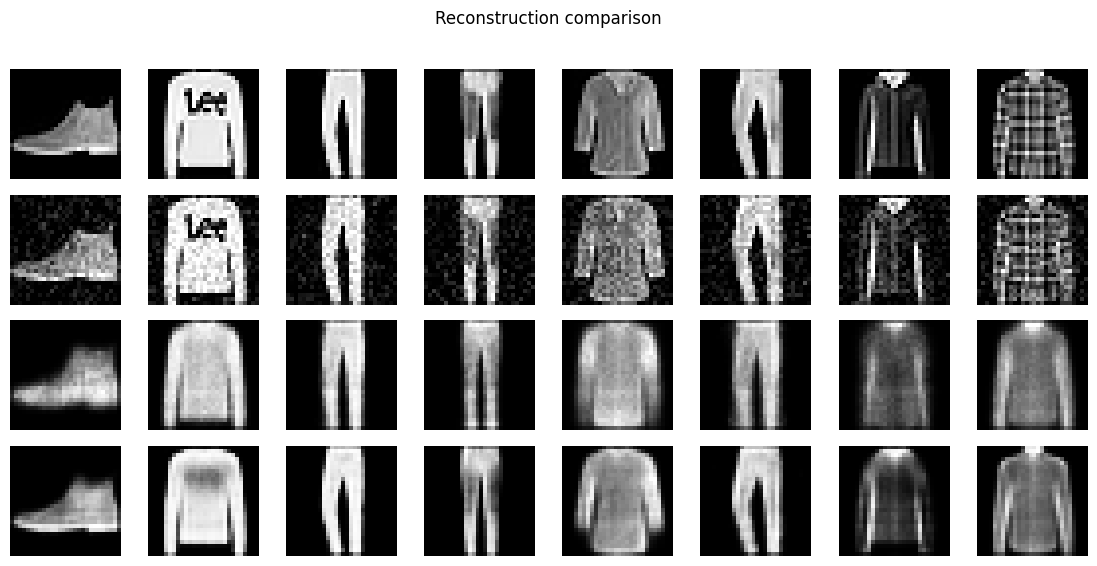

In [ ]:
best_row = results_df.sort_values('best_val_loss').iloc[0]
best_key = (int(best_row['bottleneck']), float(best_row['noise']))
best_model = models[best_key]
print('Best configuration:', best_key)

n = 8
sample_clean = x_test[:n]
sample_noisy = add_gaussian_noise(sample_clean, best_key[1])
sample_recon = best_model.predict(flatten_images(sample_noisy), verbose=0).reshape(-1,28,28)
baseline_recon = baseline_ae.predict(flatten_images(sample_clean), verbose=0).reshape(-1,28,28)

fig, axes = plt.subplots(4, n, figsize=(1.4*n, 5.5))
for i in range(n):
    axes[0, i].imshow(sample_clean[i], cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(sample_noisy[i], cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(sample_recon[i], cmap='gray'); axes[2, i].axis('off')
    axes[3, i].imshow(baseline_recon[i], cmap='gray'); axes[3, i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=10)
axes[1,0].set_ylabel('Noisy input', fontsize=10)
axes[2,0].set_ylabel('DAE recon', fontsize=10)
axes[3,0].set_ylabel('Plain AE recon', fontsize=10)
plt.suptitle('Reconstruction comparison', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/reconstruction_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### 10. PCA of the latent space

### Code Block 11: Analyse the latent space using PCA

This code cell extracts the latent representations produced by the best encoder and projects them into two dimensions using Principal Component Analysis (PCA).

**What this block does**
- passes the flattened test images through the encoder to obtain latent vectors
- reduces the latent vectors to two principal components
- plots the 2D representation with points coloured by class label
- adds axis labels, title, and legend
- saves the figure for interpretation

**Why this matters**
The latent space shows what the model has learned internally. If similar clothing classes group together in the projected space, this suggests that the encoder has captured useful structure rather than random compression.

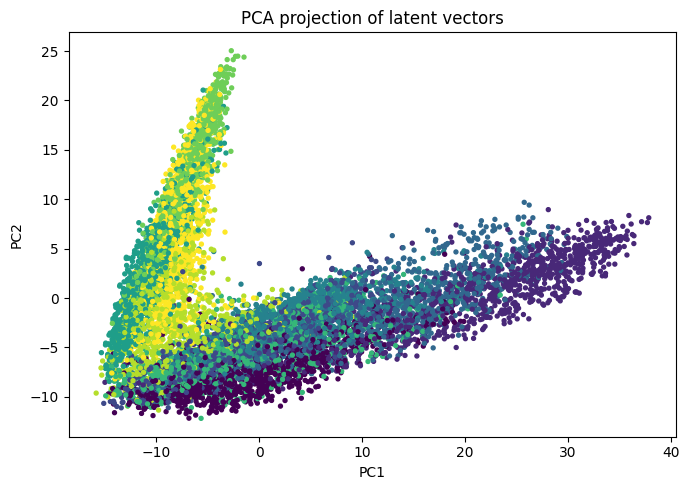

In [ ]:
latent = encoders[best_key].predict(x_test_flat, verbose=0)
pca = PCA(n_components=2, random_state=SEED)
latent_2d = pca.fit_transform(latent)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(latent_2d[:,0], latent_2d[:,1], c=y_test, s=8)
ax.set_title('PCA projection of latent vectors')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
legend = ax.legend(*scatter.legend_elements(num=10), title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.add_artist(legend)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/latent_space_pca.png', dpi=200, bbox_inches='tight')
plt.show()

### 11. Optional downstream use: classification on latent features

### Code Block 12: Test the practical usefulness of the latent features

This code cell evaluates whether the learned latent representations are useful for a downstream machine learning task.

**What this block does**
- uses the best encoder to transform the training and validation sets into latent features
- trains a logistic regression classifier on those latent features
- predicts the class labels of the validation set
- calculates the classification accuracy

**Why this matters**
A good representation should not only reconstruct images well; it should also contain useful information for other tasks. This step strengthens the tutorial by showing that the denoising autoencoder learns features that can support classification.



In [ ]:
X_latent_train = encoders[best_key].predict(x_train_flat, verbose=0)
X_latent_val = encoders[best_key].predict(x_val_flat, verbose=0)
clf = LogisticRegression(max_iter=2000)
clf.fit(X_latent_train, y_train)
val_preds = clf.predict(X_latent_val)
latent_acc = accuracy_score(y_val, val_preds)
print('Validation accuracy using latent features:', round(latent_acc, 4))

Validation accuracy using latent features: 0.8252


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 12. Save results table

### Code Block 13: Save the final results table

This final code cell exports the experiment summary and displays it in the notebook.

**What this block does**
- saves the results table as a CSV file
- keeps a clear record of all experimental outcomes
- displays the table so it can be inspected directly in the notebook

**Why this matters**
Saving the results table improves reproducibility and makes the repository easier for another user to understand and verify. It also provides a neat summary of the experiment for the GitHub repository.



In [ ]:
results_df.to_csv(f'{FIG_DIR}/results_summary.csv', index=False)
results_df

,bottleneck,noise,best_val_loss
0,16,0.1,0.293291
1,16,0.3,0.299808
2,16,0.5,0.308294
3,32,0.1,0.290067
4,32,0.3,0.296428
5,32,0.5,0.308600
6,64,0.1,0.287909
7,64,0.3,0.297919
8,64,0.5,0.310567
